In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Compute clustering in two z bins
## Define a function

In [3]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

## $w(\theta)$

In [4]:
# Create the bins array
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

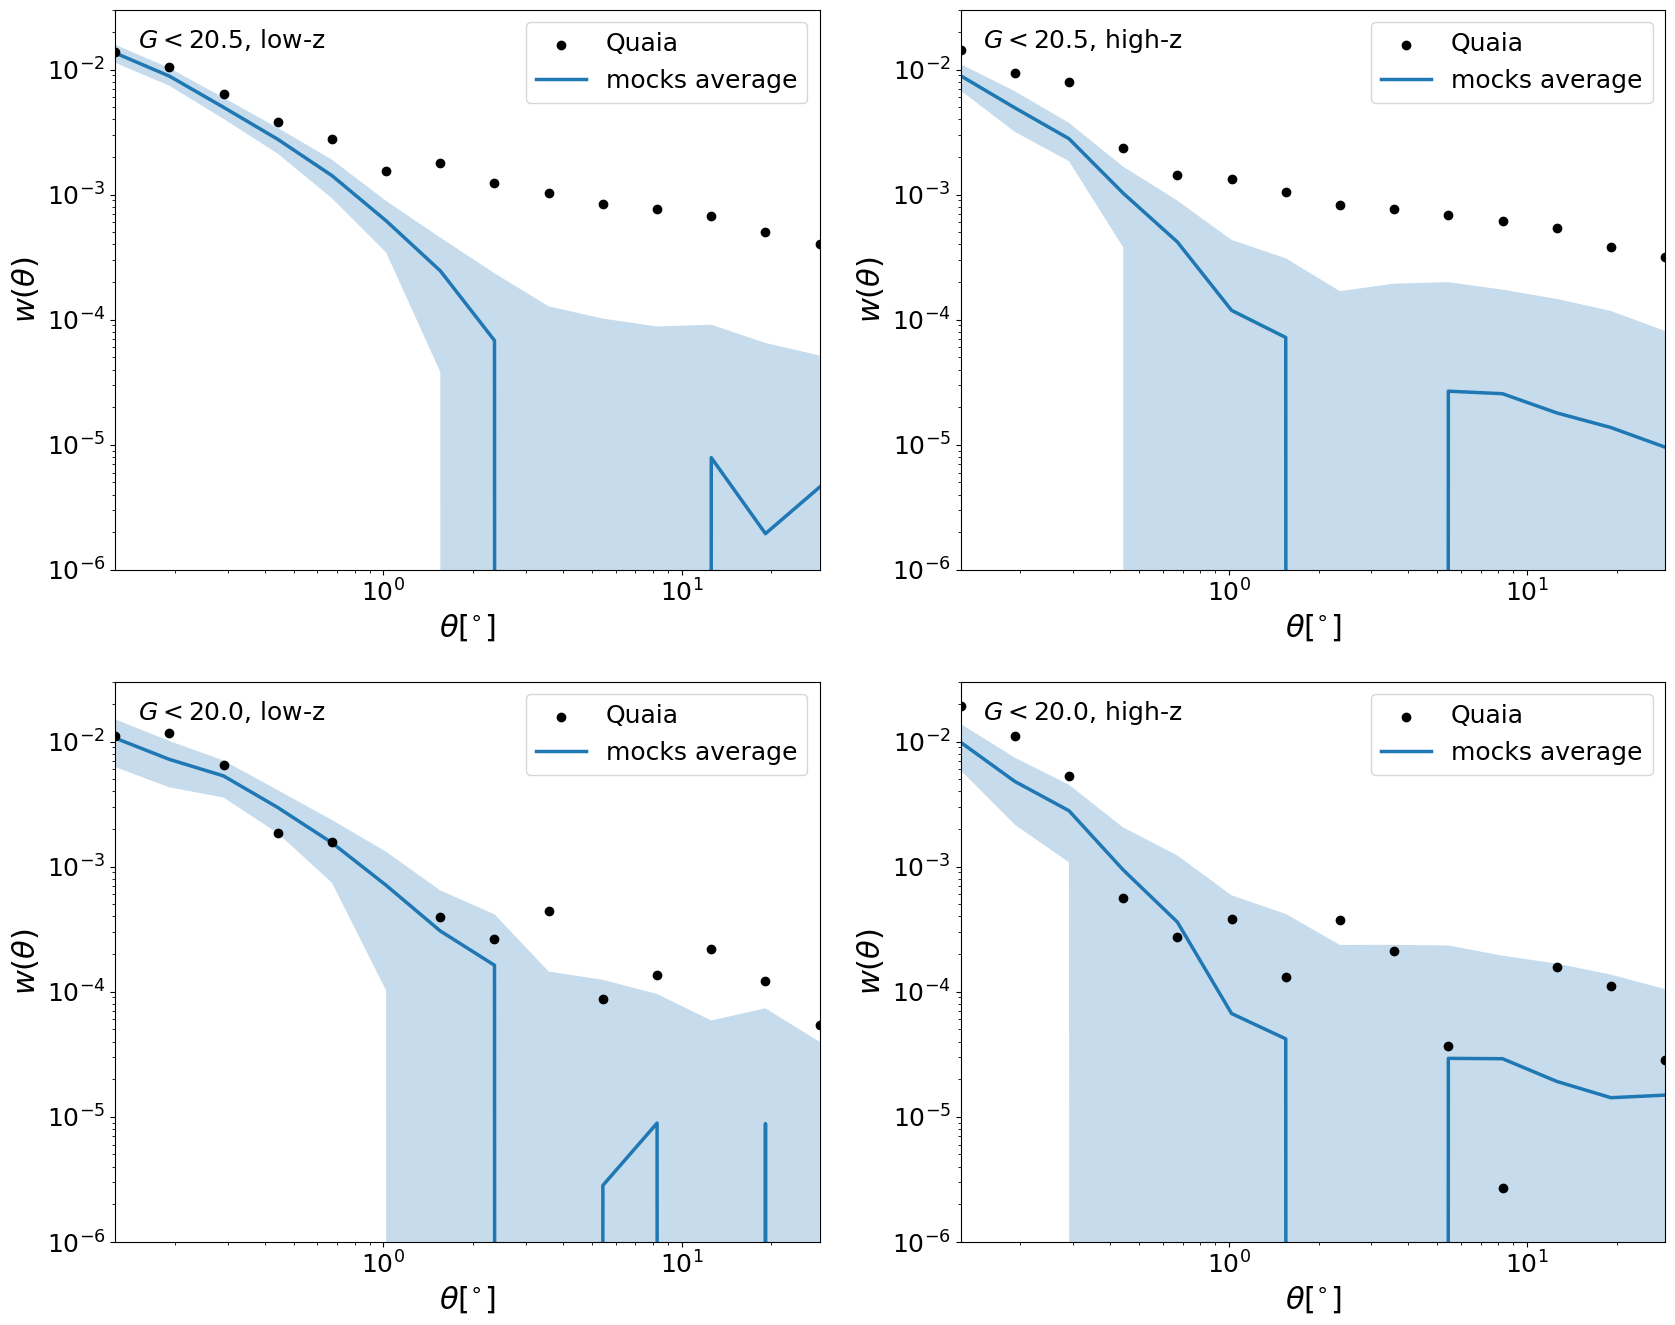

In [30]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2)

G_array = [20.5, 20]
j=0
for i in range(len(G_array)):
    for zbin, label in zip(z_array, ['low-z', 'high-z']):
        ax1 = fig.add_subplot(gs[j])
        mock = []
        
        fname = '../results/wtheta_G{:.1f}_zsplit2bin{}.npy'.format(G_array[i], zbin)
        if os.path.isfile(fname):
            ax1.scatter(quaia.recenter(thetabins), np.load(fname), color = 'black', label = 'Quaia', zorder = 3)
                
        for k in range(100):
            
            fname = '../results/wtheta_G{}_zsplit2bin{}_mock{}.npy'.format(G_array[i], zbin, k+1)
            if os.path.isfile(fname):
                mock.append(np.load(fname))
                
        if len(mock)>=1:
            mock_mean = np.mean(mock, axis = 0)
            yerr = np.std(mock, axis = 0)
            ax1.plot(quaia.recenter(thetabins), mock_mean, linewidth = 2.5, label = 'mocks average')
                         # color = cmaps[i][zbin])
            ax1.fill_between(quaia.recenter(thetabins), y1 = mock_mean - yerr, y2 = mock_mean + yerr, alpha = 0.25)

        ax1.set_xlabel(r'$\theta[^{\circ}]$')
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.set_ylabel(r"$w(\theta)$")
        ax1.text(0.15,1.5e-2,'$G<{:.1f}$, {}'.format(G_array[i], label), fontsize = 18)
        ax1.legend()
        j+=1

plt.show()

# Debug

In [7]:
# for data
# plot data
nthreads = 18
wtheta_data = {20.0: [], 20.5: []}
for G in [20.0, 20.5]:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, N_randhi_mask_zbin0, key_zbin0 = quaia.zbins(G, None, n_zbins = 1)
    wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, N_datahi_mask_zbin0, 
                                                       N_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
    wtheta_data[G].append(wtheta_datahi_zbin0)

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


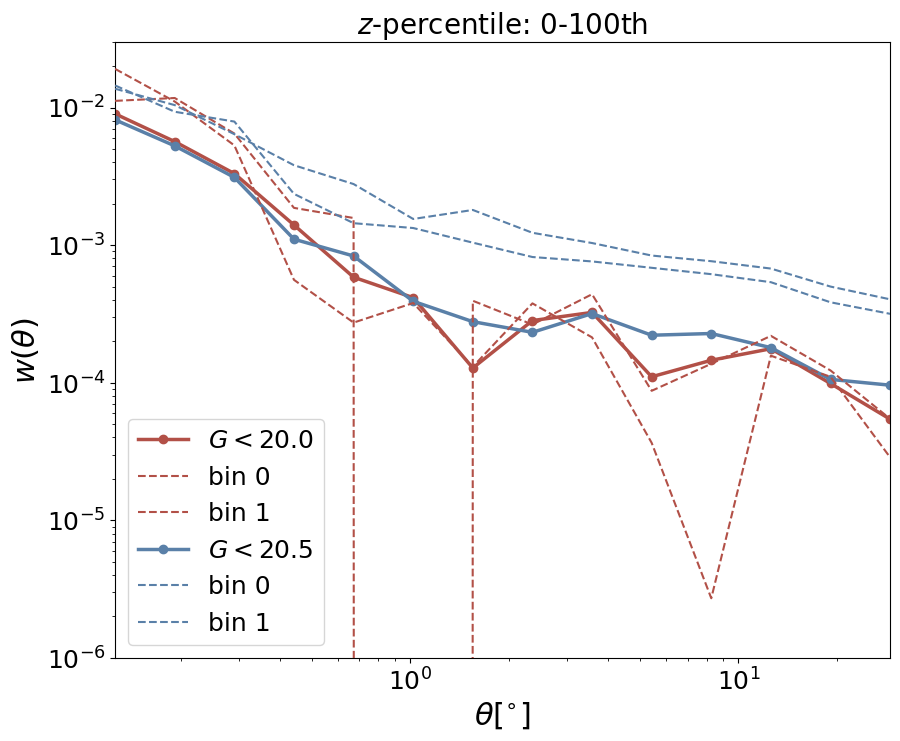

In [27]:
# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

G_array = [20.0, 20.5]
i=0
ax1 = fig.add_subplot(gs[i])
for i in range(len(G_array)):
    for zbin in [0]:
        ax1.plot(quaia.recenter(thetabins), wtheta_data[G_array[i]][zbin], marker = 'o', label = '$G<{}$'.format(G_array[i]), linewidth = 2.5,
                 color = np.mean(cmaps[i], axis = 0))
        
        for j in [0,1]:
            fname = '../results/wtheta_G{:.1f}_zsplit2bin{}.npy'.format(G_array[i], zbin+j)
            if os.path.isfile(fname):
                ax1.plot(quaia.recenter(thetabins), np.load(fname), label = 'bin {}'.format(zbin+j), zorder = 3, 
                         color = np.mean(cmaps[i], axis = 0), linestyle = '--')
ax1.set_title('$z$-percentile: 0-100th')
ax1.set_xlabel(r'$\theta[^{\circ}]$') # projected
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
ax1.set_ylim(1e-6, 3e-2)
ax1.legend()
ax1.set_ylabel(r"$w(\theta)$")

plt.show()

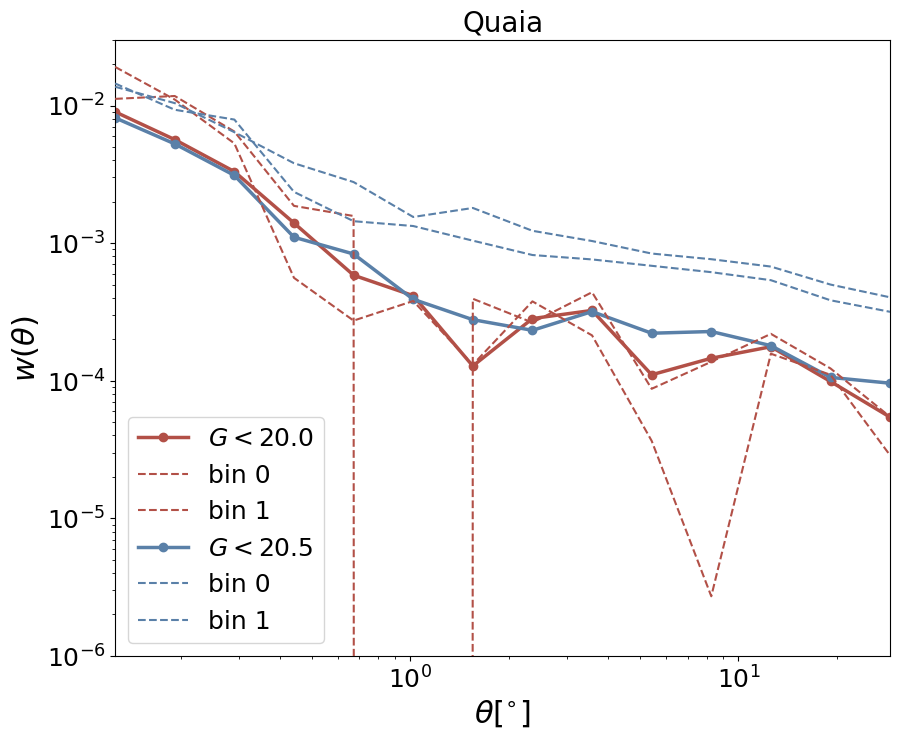

In [32]:
# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

G_array = [20.0, 20.5]
i=0
ax1 = fig.add_subplot(gs[i])
for i in range(len(G_array)):
    for zbin in [0]:
        wtheta = np.load('../results/wtheta_G{:.1f}.npy'.format(G_array[i]))
        ax1.plot(quaia.recenter(thetabins), wtheta, marker = 'o', label = '$G<{}$'.format(G_array[i]), linewidth = 2.5,
                 color = np.mean(cmaps[i], axis = 0))
        
        for j in [0,1]:
            fname = '../results/wtheta_G{:.1f}_zsplit2bin{}.npy'.format(G_array[i], zbin+j)
            if os.path.isfile(fname):
                ax1.plot(quaia.recenter(thetabins), np.load(fname), label = 'bin {}'.format(zbin+j), zorder = 3, 
                         color = np.mean(cmaps[i], axis = 0), linestyle = '--')
ax1.set_title('Quaia')
ax1.set_xlabel(r'$\theta[^{\circ}]$') # projected
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
ax1.set_ylim(1e-6, 3e-2)
ax1.legend()
ax1.set_ylabel(r"$w(\theta)$")

plt.show()